<a href="https://colab.research.google.com/github/DhruvGangwar320/GitHUB/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets #datasets is a module in scikit-learn that provides ready-made datasets
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
iris = datasets.load_iris() # load_iris() fn. Packages data + labels + metadata, Returns everything inside one object
X = iris.data
y = iris.target
feature_names = iris.feature_names # feature_names is the metadata ie a list containing headings of data
print('Features:', feature_names)
print('Classes:', iris.target_names) # its also a metadata contains classes in target variables


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
# Create DataFrame for exploration
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map(lambda i: iris.target_names[i])
# to create last column target_name in df to convert 0,1,2 from target column to setosa,virginica,etc.
df.head()
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [4]:
# Train/Test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# random_state makes randomness repeatable. Increases reproducability
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Hyperparameter tuning for k
# param_grid is nothing but a dictionary of settings you want the model to try

param_grid = {'n_neighbors': list(range(1,16)), 'weights': ['uniform','distance']}

#“Try from k = 1 to k = 15”
# uniform means All neighbors treated equally.
#distance means Closer neighbors get more importance.


knn = KNeighborsClassifier() # creating a KNN model object. like “Empty machine” Just blueprint

#GridSearchCV finds the best hyperparameters for your model using cross-validation.
# cv = 5 means 5-Fold Cross Validation
#Your training data is split into 5 parts.
#Fold 1 → Train on 4 parts, validate on 1
#Fold 2 → Train on different 4, validate on 1

grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train_s, y_train)
print('Best params:', grid.best_params_)

best_knn = grid.best_estimator_

# Evaluation
y_pred = best_knn.predict(X_test_s)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=iris.target_names))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

Best params: {'n_neighbors': 9, 'weights': 'distance'}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Visualizing decision boundaries (using first two features)
This uses a simple 2D visualization for intuition.

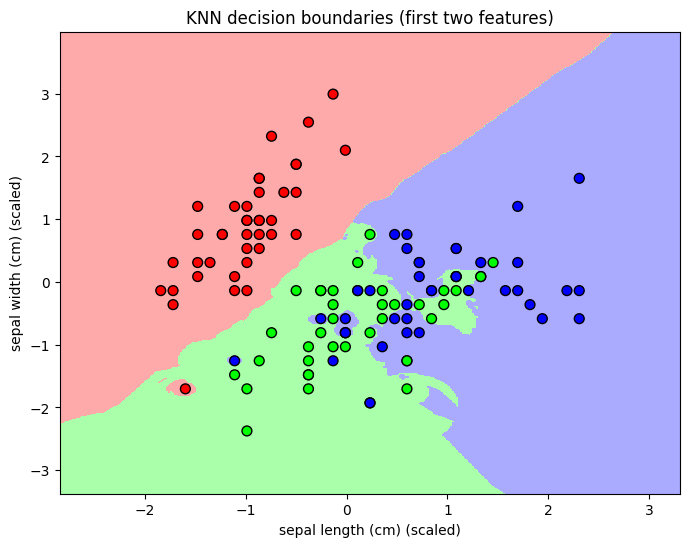

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X2 = X[:, :2] #using only two features ie. columns
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model2 = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'], weights=grid.best_params_['weights'])
model2.fit(X2_train_s, y2_train)

# Plot
h = .02  #resolution of the grid
x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1 # finding min and max value()of sepal length for plotting
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) #plootting
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=cmap_light)
plt.scatter(X2_train_s[:,0], X2_train_s[:,1], c=y2_train, cmap=cmap_bold, edgecolor='k', s=50)
plt.title('KNN decision boundaries (first two features)')
plt.xlabel(feature_names[0] + ' (scaled)')
plt.ylabel(feature_names[1] + ' (scaled)')
plt.show()